#Our AI Bias Quantifier, by shecodes**


###Importing and Analysing our Data Set

First, we imported our chosen dataset, which outlined 215 people who were either placed or unplaced for a job. This dataset includes high school grades, degrees, work experience, but also gender. We want to see if there is a bias in this gender, which may or may not be amplified later by AI.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("jockeroika/job-acceptance-prediction-system")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'job-acceptance-prediction-system' dataset.
Path to dataset files: /kaggle/input/job-acceptance-prediction-system


Files were loaded, so it can look inside the files and prints all the files within it.

In [ ]:
import os

files_in_path = os.listdir(path)
print("Files in the dataset directory:", files_in_path)

Files in the dataset directory: ['Job_Placement_Data_Enhanced.csv']


We then created a bar chart by gender, showcasing the total number of candidates who have applied to job placements.

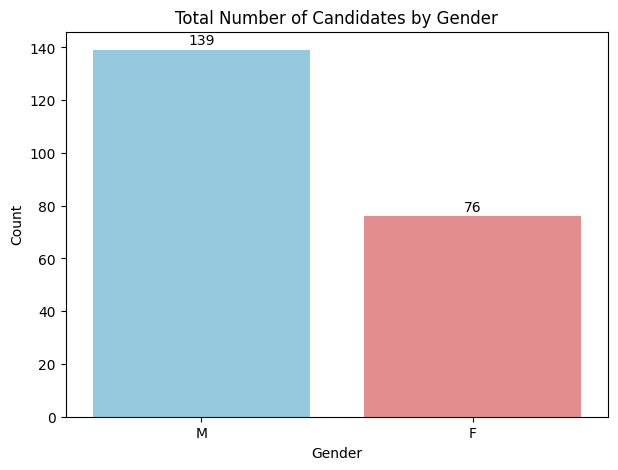

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Assuming 'path' and 'files_in_path' are already defined from previous cells
# If not, ensure these are available in the kernel's state or define them here.
# For demonstration, we'll re-load df here to make this cell self-contained against NameError

# Construct the full path to the dataset file (re-using info from earlier cells)
# NOTE: In a complete notebook flow, df would ideally be loaded once. This is for error resolution.
path = '/root/.cache/kagglehub/datasets/jockeroika/job-acceptance-prediction-system/versions/1'
files_in_path = ['Job_Placement_Data_Enhanced.csv']
data_file_name = files_in_path[0]
full_data_path = os.path.join(path, data_file_name)
df = pd.read_csv(full_data_path)

# Calculate gender counts from the DataFrame
gender_counts = df['gender'].value_counts()

# Create a DataFrame from gender_counts for easier plotting
gender_counts_df = gender_counts.reset_index()
gender_counts_df.columns = ['Gender', 'Count']

# Create the bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Count', data=gender_counts_df, palette={'M': 'skyblue', 'F': 'lightcoral'}, hue='Gender', legend=False)

# Add labels and title
plt.title('Total Number of Candidates by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Display the count values on top of the bars
for index, row in gender_counts_df.iterrows():
    plt.text(index, row['Count'] + 2, row['Count'], color='black', ha="center")

plt.show()

We can see clear representation bias, but does this lead to a bias towards men being placed? To check, we calculated the number of unplaced female and male candidates. We plotted another bar chart to visualise the ratio of placed to unplaced female and male candidates using the original data.

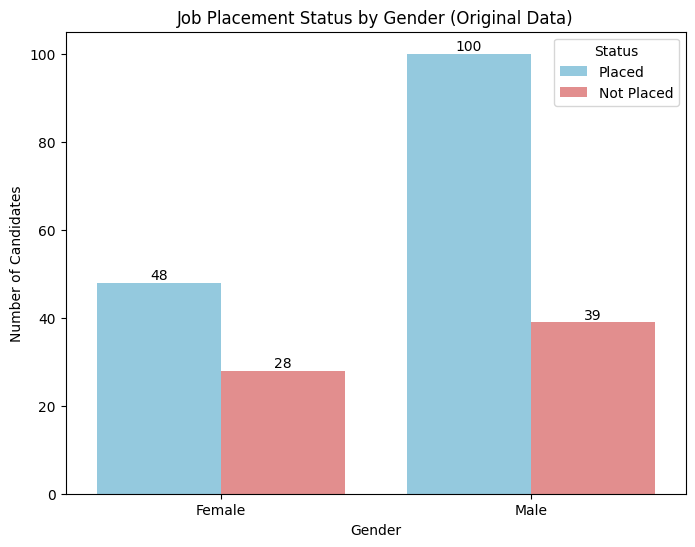

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure gender_counts is available
# Assuming df is already loaded and gender_counts is available from previous cells
# If not, add:
# gender_counts = df['gender'].value_counts()

# Calculate the number of placed females and males
num_placed_females = df[(df['gender'] == 'F') & (df['status'] == 'Placed')].shape[0]
num_placed_males = df[(df['gender'] == 'M') & (df['status'] == 'Placed')].shape[0]

# Recalculate unplaced counts
unplaced_females = gender_counts['F'] - num_placed_females
unplaced_males = gender_counts['M'] - num_placed_males

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Gender': ['Female', 'Female', 'Male', 'Male'],
    'Status': ['Placed', 'Not Placed', 'Placed', 'Not Placed'],
    'Count': [num_placed_females, unplaced_females, num_placed_males, unplaced_males]
})

# Create the stacked bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Count', hue='Status', data=plot_data, palette={'Placed': 'skyblue', 'Not Placed': 'lightcoral'})

# Add labels and title
plt.title('Job Placement Status by Gender (Original Data)')
plt.xlabel('Gender')
plt.ylabel('Number of Candidates')
plt.legend(title='Status')

# Display the count values on top of the bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d')

plt.show()

This is the code for the ratio bar chart:

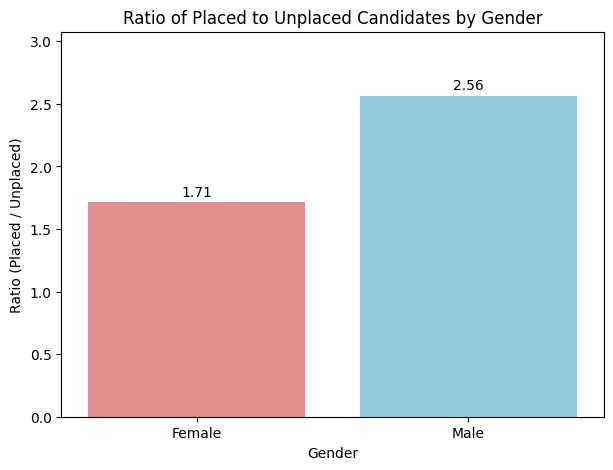

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting the ratios
ratios_data = pd.DataFrame({
    'Gender': ['Female', 'Male'],
    'Ratio (Placed/Unplaced)': [ratio_placed_unplaced_females, ratio_placed_unplaced_males]
})

# Create the bar plot with specified colors
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Ratio (Placed/Unplaced)', data=ratios_data, palette={'Female': 'lightcoral', 'Male': 'skyblue'}, hue='Gender', legend=False)

# Add labels and title for clarity
plt.title('Ratio of Placed to Unplaced Candidates by Gender')
plt.xlabel('Gender')
plt.ylabel('Ratio (Placed / Unplaced)')
plt.ylim(0, max(ratio_placed_unplaced_females, ratio_placed_unplaced_males) * 1.2) # Set y-axis limit for better visualization

# Display the ratio values on top of the bars
for index, row in ratios_data.iterrows():
    plt.text(index, row['Ratio (Placed/Unplaced)'] + 0.05, round(row['Ratio (Placed/Unplaced)'], 2), color='black', ha="center")

plt.show()

However, we wanted to identify other variables, and see if those are the reason for this supposed bias. So, we filtered the candidates to find the number of candidates with an interview score above 75, which was then represented on another graph.

Number of females with interview score > 75: 30
Number of males with interview score > 75: 66


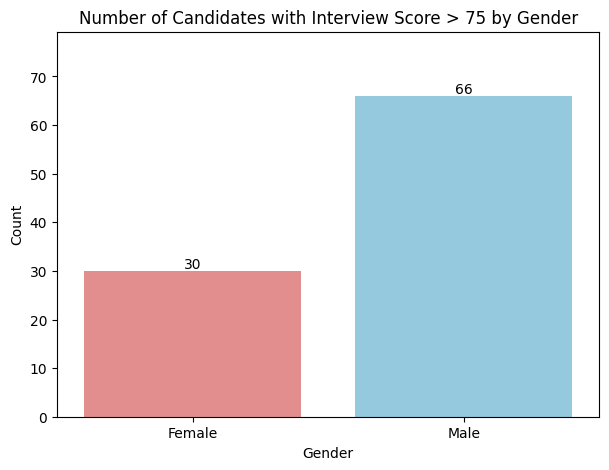

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for females with an interview score > 75
high_interview_females = df[(df['gender'] == 'F') & (df['interview_score'] > 75)]
num_high_interview_females = high_interview_females.shape[0]

# Filter for males with an interview score > 75
high_interview_males = df[(df['gender'] == 'M') & (df['interview_score'] > 75)]
num_high_interview_males = high_interview_males.shape[0]

print(f"Number of females with interview score > 75: {num_high_interview_females}")
print(f"Number of males with interview score > 75: {num_high_interview_males}")

# Create a DataFrame for plotting
interview_score_data = pd.DataFrame({
    'Gender': ['Female', 'Male'],
    'Count': [num_high_interview_females, num_high_interview_males]
})

# Create the bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Count', data=interview_score_data, palette={'Female': 'lightcoral', 'Male': 'skyblue'}, hue='Gender', legend=False)

# Add labels and title for clarity
plt.title('Number of Candidates with Interview Score > 75 by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.ylim(0, max(num_high_interview_females, num_high_interview_males) * 1.2) # Set y-axis limit for better visualization

# Display the count values on top of the bars
for index, row in interview_score_data.iterrows():
    plt.text(index, row['Count'] + 0.5, row['Count'], color='black', ha="center")

plt.show()

We can see that men were far better at interview scores, which may explain the larger number of male placemetns. We did the same for work experience.

Number of females with work experience: 22
Number of males with work experience: 52


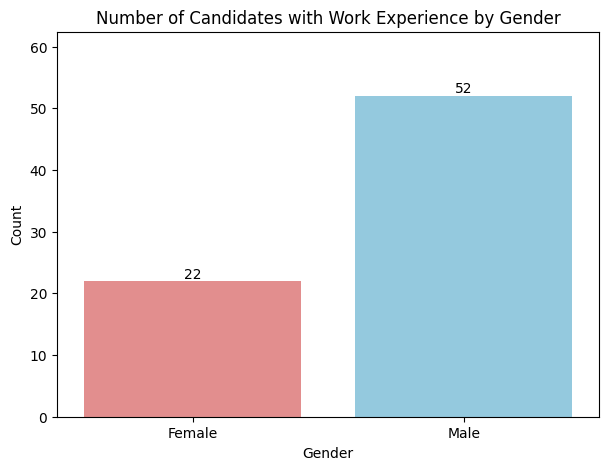

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Chart 1: Number of Females and Males with Work Experience ---

# Filter for candidates with work experience
experienced_candidates = df[df['work_experience'] == 'Yes']

# Count the number of experienced females and males
num_experienced_females = experienced_candidates[experienced_candidates['gender'] == 'F'].shape[0]
num_experienced_males = experienced_candidates[experienced_candidates['gender'] == 'M'].shape[0]

print(f"Number of females with work experience: {num_experienced_females}")
print(f"Number of males with work experience: {num_experienced_males}")

# Create a DataFrame for plotting
experienced_data = pd.DataFrame({
    'Gender': ['Female', 'Male'],
    'Count': [num_experienced_females, num_experienced_males]
})

# Create the bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Count', data=experienced_data, palette={'Female': 'lightcoral', 'Male': 'skyblue'}, hue='Gender', legend=False)

# Add labels and title for clarity
plt.title('Number of Candidates with Work Experience by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.ylim(0, max(num_experienced_females, num_experienced_males) * 1.2) # Set y-axis limit for better visualization

# Display the count values on top of the bars
for index, row in experienced_data.iterrows():
    plt.text(index, row['Count'] + 0.5, row['Count'], color='black', ha="center")

plt.show()

Here, we see more men are experienced (which is a big problem and we should increase work experience oppurtunities for women- kind of like this Hackathon for International Women's Day!) We also graphed the ratio of experienced to non experienced candidates by gender. to highlight this.

Ratio of Experienced to Non-Experienced Females: 0.41
Ratio of Experienced to Non-Experienced Males: 0.60


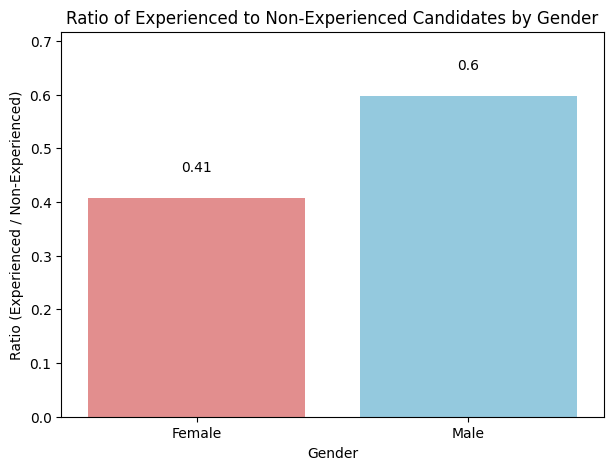

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Chart 2: Ratio of Experienced to Non-Experienced Candidates by Gender ---

# Ensure gender_counts is defined (if not already in current session)
gender_counts = df['gender'].value_counts()

# Total females and males (assuming gender_counts is from the whole df)
total_females = gender_counts['F']
total_males = gender_counts['M']

# Number of females and males with work experience (from previous step)
num_experienced_females = df[(df['gender'] == 'F') & (df['work_experience'] == 'Yes')].shape[0]
num_experienced_males = df[(df['gender'] == 'M') & (df['work_experience'] == 'Yes')].shape[0]

# Number of females and males without work experience
num_non_experienced_females = total_females - num_experienced_females
num_non_experienced_males = total_males - num_experienced_males

# Calculate ratios of experienced to non-experienced (handle division by zero)
ratio_experienced_non_experienced_females = num_experienced_females / num_non_experienced_females if num_non_experienced_females > 0 else 0
ratio_experienced_non_experienced_males = num_experienced_males / num_non_experienced_males if num_non_experienced_males > 0 else 0

print(f"Ratio of Experienced to Non-Experienced Females: {ratio_experienced_non_experienced_females:.2f}")
print(f"Ratio of Experienced to Non-Experienced Males: {ratio_experienced_non_experienced_males:.2f}")

# Create a DataFrame for plotting the ratios
ratios_work_experience_data = pd.DataFrame({
    'Gender': ['Female', 'Male'],
    'Ratio (Experienced/Non-Experienced)': [ratio_experienced_non_experienced_females, ratio_experienced_non_experienced_males]
})

# Create the bar plot with specified colors
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Ratio (Experienced/Non-Experienced)', data=ratios_work_experience_data, palette={'Female': 'lightcoral', 'Male': 'skyblue'}, hue='Gender', legend=False)

# Add labels and title for clarity
plt.title('Ratio of Experienced to Non-Experienced Candidates by Gender')
plt.xlabel('Gender')
plt.ylabel('Ratio (Experienced / Non-Experienced)')
plt.ylim(0, max(ratio_experienced_non_experienced_females, ratio_experienced_non_experienced_males) * 1.2) # Set y-axis limit for better visualization

# Display the ratio values on top of the bars
for index, row in ratios_work_experience_data.iterrows():
    plt.text(index, row['Ratio (Experienced/Non-Experienced)'] + 0.05, round(row['Ratio (Experienced/Non-Experienced)'], 2), color='black', ha="center")

plt.show()

Finally, we calculated our Disparate Impact Ratio (positive outcomes for protected group/postive outcomes for non-protected group) and confirmed that our dataset isn't actually biased.

In [ ]:
# Calculate placement rates from original data
placement_rate_females = num_placed_females / gender_counts['F'] if gender_counts['F'] > 0 else 0
placement_rate_males = num_placed_males / gender_counts['M'] if gender_counts['M'] > 0 else 0

# Calculate the Disparate Impact Ratio (DIR) for original data
disparate_impact_ratio = placement_rate_females / placement_rate_males if placement_rate_males > 0 else float('inf')

print(f"Disparate Impact Ratio (Original Data): {disparate_impact_ratio:.4f}")

Disparate Impact Ratio (Original Data): 0.8779


To confirm our conclusion that the dataset isn't biased, we performed a Chi-Squared Test. We first created a contingency table from the original DataFrame `df` showing the counts of 'Placed' and 'Not Placed' individuals for both 'Male' and 'Female' genders. This table will be the input for the Chi-squared test.


In [ ]:
contingency_table = pd.crosstab(df['gender'], df['status'])
print("Contingency Table (Gender vs. Status):")
print(contingency_table)

Contingency Table (Gender vs. Status):
status  Not Placed  Placed
gender                    
F               28      48
M               39     100


We performed an independence test using `scipy.stats.chi2_contingency` on the `contingency_table` to assess if there is a statistically significant association between gender and placement status.



In [ ]:
from scipy.stats import chi2_contingency

# Perform Chi-squared test
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)

print("\nChi-squared Test Results:")
print(f"Chi-squared Statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")
print("Expected Frequencies (if no association):")
print(expected_frequencies.round(2))


Chi-squared Test Results:
Chi-squared Statistic: 1.3818
P-value: 0.2398
Degrees of Freedom: 1
Expected Frequencies (if no association):
[[23.68 52.32]
 [43.32 95.68]]


**Test Results:**
*   **Chi-squared Statistic:** `1.3818`
*   **P-value:** `0.2398`
*   **Degrees of Freedom:** `1`


The p-value (0.2398) is greater than the commonly used significance level of 0.05. This means we **do not have sufficient statistical evidence to reject the null hypothesis**. The null hypothesis states that there is no association between gender and placement status.


Based on the Chi-squared test, there is **no statistically significant association between gender and job placement status in the original dataset**.

Therefore, our disparate impact ratio of 0.8779, showing there is no significant bias, is supported by our Chi-squared test and so we can conclude **there is no statistically significant evidence of gender-based bias in job placement within the original dataset**.

##Creating and Analysing AI Systems

We now created our AI systems, which have the task of using the dataset to predict placements of random people. We first selected the specific file we needed and created a full file path, loading the dataset into a df. we then displayed the first 5 rows to confirm that it was loaded successfully.

In [ ]:
import pandas as pd
import os

# Construct the full path to the dataset file
data_file_name = files_in_path[0]
full_data_path = os.path.join(path, data_file_name)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(full_data_path)

# Display the first few rows of the DataFrame
print("DataFrame loaded successfully. First 5 rows:")
print(df.head())

DataFrame loaded successfully. First 5 rows:
  gender  ssc_percentage ssc_board  hsc_percentage hsc_board hsc_subject  \
0      M           67.00    Others           91.00    Others    Commerce   
1      M           79.33   Central           78.33    Others     Science   
2      M           65.00   Central           68.00   Central        Arts   
3      M           56.00   Central           52.00   Central     Science   
4      M           85.80   Central           73.60   Central    Commerce   

   degree_percentage undergrad_degree work_experience  emp_test_percentage  \
0              58.00         Sci&Tech              No                 55.0   
1              77.48         Sci&Tech             Yes                 86.5   
2              64.00        Comm&Mgmt              No                 75.0   
3              52.00         Sci&Tech              No                 66.0   
4              73.30        Comm&Mgmt              No                 96.8   

  specialisation  mba_percent

We now confirmed the number of males and females placed to use in our later codes.



In [ ]:
print("DataFrame Columns:", df.columns.tolist())
print("Unique values in 'gender' column:", df['gender'].unique())
print("Unique values in 'status' column:", df['status'].unique())

DataFrame Columns: ['gender', 'ssc_percentage', 'ssc_board', 'hsc_percentage', 'hsc_board', 'hsc_subject', 'degree_percentage', 'undergrad_degree', 'work_experience', 'emp_test_percentage', 'specialisation', 'mba_percent', 'status', 'years_experience', 'skills_match_percent', 'num_certifications', 'internship_completed', 'interview_score', 'company_tier', 'job_competition_level']
Unique values in 'gender' column: ['M' 'F']
Unique values in 'status' column: ['Placed' 'Not Placed']


In [ ]:
placed_females_df = df[(df['gender'] == 'F') & (df['status'] == 'Placed')]
num_placed_females = placed_females_df.shape[0]
print(f"Number of placed females: {num_placed_females}")

Number of placed females: 48


In [ ]:
placed_males_df = df[(df['gender'] == 'M') & (df['status'] == 'Placed')]
num_placed_males = placed_males_df.shape[0]
print(f"Number of placed males: {num_placed_males}")

Number of placed males: 100


 The next few cells of code involve one-hot encoding categorical features, splitting the data into training and testing sets, training both models, and then evaluating their performance using accuracy, precision, recall, and F1-score. Finally, summarize and compare the results of both models.

Here, we separated the features (X) from the target variable (y), which is 'status', to prepare the data for encoding and splitting.



In [ ]:
X = df.drop('status', axis=1)
y = df['status']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
  gender  ssc_percentage ssc_board  hsc_percentage hsc_board hsc_subject  \
0      M           67.00    Others           91.00    Others    Commerce   
1      M           79.33   Central           78.33    Others     Science   
2      M           65.00   Central           68.00   Central        Arts   
3      M           56.00   Central           52.00   Central     Science   
4      M           85.80   Central           73.60   Central    Commerce   

   degree_percentage undergrad_degree work_experience  emp_test_percentage  \
0              58.00         Sci&Tech              No                 55.0   
1              77.48         Sci&Tech             Yes                 86.5   
2              64.00        Comm&Mgmt              No                 75.0   
3              52.00         Sci&Tech              No                 66.0   
4              73.30        Comm&Mgmt              No                 96.8   

  specialisation  mba_percent  years_experience  skills

We then made our status colum numerical, with 0 as unplaced and 1 as placed


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the 'status' column
y_encoded = le.fit_transform(y)

print("Encoded target (y_encoded) head:")
print(y_encoded[:5])
print("Unique values in y_encoded:", le.classes_)

# Overwrite y with the encoded version
y = pd.Series(y_encoded, name='status')

Encoded target (y_encoded) head:
[1 1 1 0 1]
Unique values in y_encoded: ['Not Placed' 'Placed']


We then used one-hot encoding for non numric columns within the features dataframe.


In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in X:", categorical_cols.tolist())

Categorical columns in X: ['gender', 'ssc_board', 'hsc_board', 'hsc_subject', 'undergrad_degree', 'work_experience', 'specialisation', 'company_tier', 'job_competition_level']


In [ ]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Features (X) after one-hot encoding:")
print(X.head())

Features (X) after one-hot encoding:
   ssc_percentage  hsc_percentage  degree_percentage  emp_test_percentage  \
0           67.00           91.00              58.00                 55.0   
1           79.33           78.33              77.48                 86.5   
2           65.00           68.00              64.00                 75.0   
3           56.00           52.00              52.00                 66.0   
4           85.80           73.60              73.30                 96.8   

   mba_percent  years_experience  skills_match_percent  num_certifications  \
0        58.80                 3                    98                   1   
1        66.28                 4                    88                   1   
2        57.80                 2                    41                   1   
3        59.43                 4                    41                   0   
4        55.50                 4                    67                   0   

   internship_completed  interv

We then checked that we split our data correctly to avoid errors.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (150, 23)
Shape of X_test: (65, 23)
Shape of y_train: (150,)
Shape of y_test: (65,)


### Logistic Regression Model:
This involves using the training and testing sets and then fitting the model.


**Reasoning**:
We used the import `LogisticRegression` from `sklearn.linear_model` to help us.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


We then evaluated metrics of our model such as accuracy, precision, recall, and F1-score. This will help understand how well this model predicts job placement, and explain if the model produced bias or not.


**Reasoning**:
I will first make predictions on the test set using the trained Logistic Regression model, then calculate and print the accuracy, precision, recall, and F1-score to evaluate its performance.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate evaluation metrics
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

# Print the metrics
print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.8308
Precision: 0.8511
Recall: 0.9091
F1-Score: 0.8791


### Random Forest Model:
We used Scikit-learn on the preprocessed training data again.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


We then analysed metrics again for Random Forest model this time.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Print the metrics
print(f"Random Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Random Forest Model Performance:
Accuracy: 0.7846
Precision: 0.7778
Recall: 0.9545
F1-Score: 0.8571


###Decision Tree Model

We did the same process to train decision tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


And evaluated metrics again.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Print the metrics
print(f"Decision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

Decision Tree Model Performance:
Accuracy: 0.7692
Precision: 0.8222
Recall: 0.8409
F1-Score: 0.8315


We then created a dataframe to compare each model's metrics, and analysed.



In [ ]:
import pandas as pd

# Create a dictionary to store the metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [accuracy_log_reg, accuracy_rf, accuracy_dt],
    'Precision': [precision_log_reg, precision_rf, precision_dt],
    'Recall': [recall_log_reg, recall_rf, recall_dt],
    'F1-Score': [f1_log_reg, f1_rf, f1_dt]
}

# Create a DataFrame from the dictionary
metrics_df = pd.DataFrame(metrics_data)

print("\nModel Performance Comparison:")
print(metrics_df.round(4))

# Provide a brief analysis
print("\nAnalysis:")
# Find the best model based on accuracy (can be adjusted for other metrics)
best_model_accuracy = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
best_model_recall = metrics_df.loc[metrics_df['Recall'].idxmax()]
best_model_precision = metrics_df.loc[metrics_df['Precision'].idxmax()]

print(f"The model with the highest Accuracy is {best_model_accuracy['Model']} with an Accuracy of {best_model_accuracy['Accuracy']:.4f}.")
print(f"The model with the highest Recall is {best_model_recall['Model']} with a Recall of {best_model_recall['Recall']:.4f}.")
print(f"The model with the highest Precision is {best_model_precision['Model']} with a Precision of {best_model_precision['Precision']:.4f}.")

print("\nOverall, Logistic Regression performed best in terms of Accuracy and Precision. Random Forest showed the highest Recall. Decision Tree had slightly lower performance across most metrics compared to Logistic Regression, but better Recall than Logistic Regression.")
print("The choice of the 'best' model depends on the specific business need and which metric (Accuracy, Precision, or Recall) is most critical.")


Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8308     0.8511  0.9091    0.8791
1        Random Forest    0.7846     0.7778  0.9545    0.8571
2        Decision Tree    0.7692     0.8222  0.8409    0.8315

Analysis:
The model with the highest Accuracy is Logistic Regression with an Accuracy of 0.8308.
The model with the highest Recall is Random Forest with a Recall of 0.9545.
The model with the highest Precision is Logistic Regression with a Precision of 0.8511.

Overall, Logistic Regression performed best in terms of Accuracy and Precision. Random Forest showed the highest Recall. Decision Tree had slightly lower performance across most metrics compared to Logistic Regression, but better Recall than Logistic Regression.
The choice of the 'best' model depends on the specific business need and which metric (Accuracy, Precision, or Recall) is most critical.


If minimizing false positives (incorrectly predicting someone is placed) and overall correctness are priorities, the Logistic Regression model might be preferred due to its higher precision (0.8511) and accuracy (0.8308).
If minimizing false negatives (failing to identify placed candidates) is critical, the Random Forest model could be more suitable due to its superior recall (0.9545).


Anyway, let's get back to calculating bias. We now want to check the Disparate Impact Ratio for each model. We did this by calculating the ratio of placed to unplaced in each gender, and then dividing the ratio for women by the ratio for men.

In [ ]:
import pandas as pd

# Create a DataFrame for analysis with test data and predictions
analysis_df = X_test.copy()
analysis_df['actual_status'] = y_test
analysis_df['predicted_status_log_reg'] = y_pred_log_reg
analysis_df['predicted_status_rf'] = y_pred_rf

# --- Analysis for Logistic Regression Predictions ---

# Get total counts of females and males in the test set (using 'gender_M' column)
total_test_females = analysis_df[analysis_df['gender_M'] == False].shape[0]
total_test_males = analysis_df[analysis_df['gender_M'] == True].shape[0]

# Get predicted placed counts for females (gender_M = False, predicted_status_log_reg = 1)
predicted_placed_females_log_reg = analysis_df[(analysis_df['gender_M'] == False) & (analysis_df['predicted_status_log_reg'] == 1)].shape[0]

# Get predicted placed counts for males (gender_M = True, predicted_status_log_reg = 1)
predicted_placed_males_log_reg = analysis_df[(analysis_df['gender_M'] == True) & (analysis_df['predicted_status_log_reg'] == 1)].shape[0]

print(f"\n--- Logistic Regression Model Predictions ---")
print(f"Total females in test set: {total_test_females}")
print(f"Total males in test set: {total_test_males}")
print(f"Predicted placed females (Log Reg): {predicted_placed_females_log_reg}")
print(f"Predicted placed males (Log Reg): {predicted_placed_males_log_reg}")

# Calculate predicted placement rate for females (Log Reg)
predicted_placement_rate_females_log_reg = predicted_placed_females_log_reg / total_test_females if total_test_females > 0 else 0
print(f"Predicted Placement Rate for Females (Log Reg): {predicted_placement_rate_females_log_reg:.4f}")

# Calculate predicted placement rate for males (Log Reg)
predicted_placement_rate_males_log_reg = predicted_placed_males_log_reg / total_test_males if total_test_males > 0 else 0
print(f"Predicted Placement Rate for Males (Log Reg): {predicted_placement_rate_males_log_reg:.4f}")

# Calculate the Disparate Impact Ratio (DIR) with Females as the protected group (Log Reg)
# Ratio = (Placement Rate of Protected Group) / (Placement Rate of Non-Protected Group)
disparate_impact_ratio_log_reg = predicted_placement_rate_females_log_reg / predicted_placement_rate_males_log_reg if predicted_placement_rate_males_log_reg > 0 else float('inf')

print(f"\nDisparate Impact Ratio (Females as Protected Group, Log Reg): {disparate_impact_ratio_log_reg:.4f}")

# Interpret the ratio based on the 4/5ths rule (Log Reg)
if disparate_impact_ratio_log_reg < 0.8:
    print("Conclusion (Log Reg): There may be evidence of disparate impact against females based on predictions.")
elif disparate_impact_ratio_log_reg > 1.25:
    print("Conclusion (Log Reg): There may be evidence of adverse impact against males based on predictions.")
else:
    print("Conclusion (Log Reg): The ratio is within the acceptable range (0.8 to 1.25), suggesting no significant disparate impact based on Log Reg predictions.")


# --- Analysis for Random Forest Predictions ---

# Get predicted placed counts for females (gender_M = False, predicted_status_rf = 1)
predicted_placed_females_rf = analysis_df[(analysis_df['gender_M'] == False) & (analysis_df['predicted_status_rf'] == 1)].shape[0]

# Get predicted placed counts for males (gender_M = True, predicted_status_rf = 1)
predicted_placed_males_rf = analysis_df[(analysis_df['gender_M'] == True) & (analysis_df['predicted_status_rf'] == 1)].shape[0]

print(f"\n--- Random Forest Model Predictions ---")
print(f"Total females in test set: {total_test_females}")
print(f"Total males in test set: {total_test_males}")
print(f"Predicted placed females (RF): {predicted_placed_females_rf}")
print(f"Predicted placed males (RF): {predicted_placed_males_rf}")

# Calculate predicted placement rate for females (RF)
predicted_placement_rate_females_rf = predicted_placed_females_rf / total_test_females if total_test_females > 0 else 0
print(f"Predicted Placement Rate for Females (RF): {predicted_placement_rate_females_rf:.4f}")

# Calculate predicted placement rate for males (RF)
predicted_placement_rate_males_rf = predicted_placed_males_rf / total_test_males if total_test_males > 0 else 0
print(f"Predicted Placement Rate for Males (RF): {predicted_placement_rate_males_rf:.4f}")

# Calculate the Disparate Impact Ratio (DIR) with Females as the protected group (RF)
# Ratio = (Placement Rate of Protected Group) / (Placement Rate of Non-Protected Group)
disparate_impact_ratio_rf = predicted_placement_rate_females_rf / predicted_placement_rate_males_rf if predicted_placement_rate_males_rf > 0 else float('inf')

print(f"\nDisparate Impact Ratio (Females as Protected Group, RF): {disparate_impact_ratio_rf:.4f}")

# Interpret the ratio based on the 4/5ths rule (RF)
if disparate_impact_ratio_rf < 0.8:
    print("Conclusion (RF): There may be evidence of disparate impact against females based on predictions.")
elif disparate_impact_ratio_rf > 1.25:
    print("Conclusion (RF): There may be evidence of adverse impact against males based on predictions.")
else:
    print("Conclusion (RF): The ratio is within the acceptable range (0.8 to 1.25), suggesting no significant disparate impact based on RF predictions.")

#Add Decision Tree predictions to analysis_df
analysis_df['predicted_status_dt'] = y_pred_dt

# --- Analysis for Decision Tree Predictions ---

# Get total counts of females and males in the test set (using 'gender_M' column)
# total_test_females and total_test_males are already defined from previous steps

# Get predicted placed counts for females (gender_M = False, predicted_status_dt = 1)
predicted_placed_females_dt = analysis_df[(analysis_df['gender_M'] == False) & (analysis_df['predicted_status_dt'] == 1)].shape[0]

# Get predicted placed counts for males (gender_M = True, predicted_status_dt = 1)
predicted_placed_males_dt = analysis_df[(analysis_df['gender_M'] == True) & (analysis_df['predicted_status_dt'] == 1)].shape[0]

print(f"\n--- Decision Tree Model Predictions ---")
print(f"Total females in test set: {total_test_females}")
print(f"Total males in test set: {total_test_males}")
print(f"Predicted placed females (DT): {predicted_placed_females_dt}")
print(f"Predicted placed males (DT): {predicted_placed_males_dt}")

# Calculate predicted placement rate for females (DT)
predicted_placement_rate_females_dt = predicted_placed_females_dt / total_test_females if total_test_females > 0 else 0
print(f"Predicted Placement Rate for Females (DT): {predicted_placement_rate_females_dt:.4f}")

# Calculate predicted placement rate for males (DT)
predicted_placement_rate_males_dt = predicted_placed_males_dt / total_test_males if total_test_males > 0 else 0
print(f"Predicted Placement Rate for Males (DT): {predicted_placement_rate_males_dt:.4f}")

# Calculate the Disparate Impact Ratio (DIR) with Females as the protected group (DT)
# Ratio = (Placement Rate of Protected Group) / (Placement Rate of Non-Protected Group)
disparate_impact_ratio_dt = predicted_placement_rate_females_dt / predicted_placement_rate_males_dt if predicted_placement_rate_males_dt > 0 else float('inf')

print(f"\nDisparate Impact Ratio (Females as Protected Group, DT): {disparate_impact_ratio_dt:.4f}")

# Interpret the ratio based on the 4/5ths rule (DT)
if disparate_impact_ratio_dt < 0.8:
    print("Conclusion (DT): There may be evidence of disparate impact against females based on predictions.")
elif disparate_impact_ratio_dt > 1.25:
    print("Conclusion (DT): There may be evidence of adverse impact against males based on predictions.")
else:
    print("Conclusion (DT): The ratio is within the acceptable range (0.8 to 1.25), suggesting no significant disparate impact based on DT predictions.")


--- Logistic Regression Model Predictions ---
Total females in test set: 24
Total males in test set: 41
Predicted placed females (Log Reg): 13
Predicted placed males (Log Reg): 34
Predicted Placement Rate for Females (Log Reg): 0.5417
Predicted Placement Rate for Males (Log Reg): 0.8293

Disparate Impact Ratio (Females as Protected Group, Log Reg): 0.6532
Conclusion (Log Reg): There may be evidence of disparate impact against females based on predictions.

--- Random Forest Model Predictions ---
Total females in test set: 24
Total males in test set: 41
Predicted placed females (RF): 18
Predicted placed males (RF): 36
Predicted Placement Rate for Females (RF): 0.7500
Predicted Placement Rate for Males (RF): 0.8780

Disparate Impact Ratio (Females as Protected Group, RF): 0.8542
Conclusion (RF): The ratio is within the acceptable range (0.8 to 1.25), suggesting no significant disparate impact based on RF predictions.

--- Decision Tree Model Predictions ---
Total females in test set: 24

In [ ]:
import pandas as pd

# Create a dictionary to store the Disparate Impact Ratios
dir_data = {
    'Source': ['Original Data', 'Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Disparate Impact Ratio': [disparate_impact_ratio, disparate_impact_ratio_log_reg, disparate_impact_ratio_rf, disparate_impact_ratio_dt]
}

# Create a DataFrame from the dictionary
dir_df = pd.DataFrame(dir_data)

print("\nDisparate Impact Ratio Comparison (Females as Protected Group):")
print(dir_df.round(4))


Disparate Impact Ratio Comparison (Females as Protected Group):
                Source  Disparate Impact Ratio
0        Original Data                  0.8779
1  Logistic Regression                  0.6532
2        Random Forest                  0.8542
3        Decision Tree                  0.8542


And of course, we plotted this beside the baseline (the 4/5ths rule).

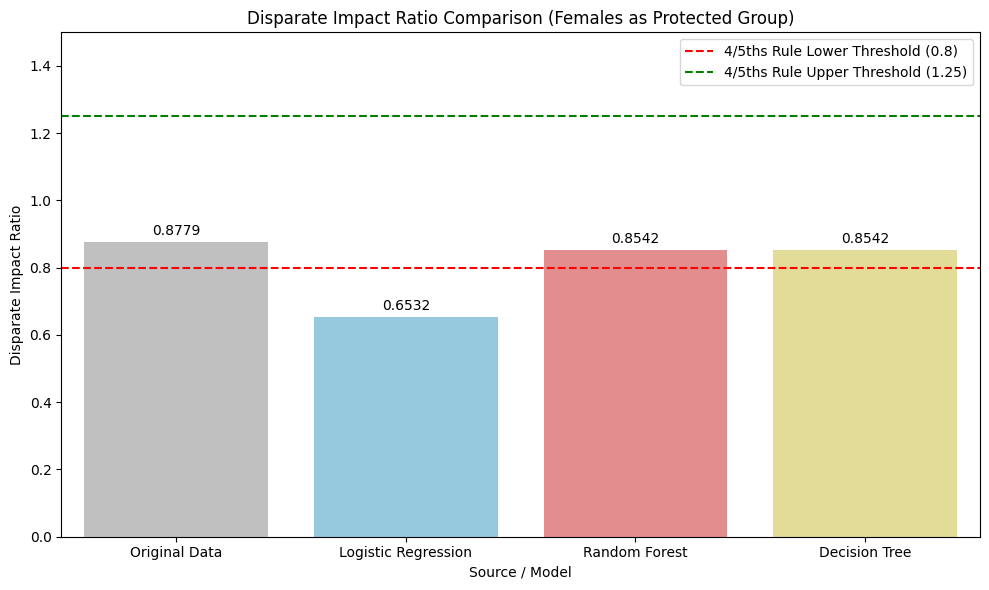

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming dir_df is available from previous executions
# dir_data = {
#     'Source': ['Original Data', 'Logistic Regression', 'Random Forest', 'Decision Tree'],
#     'Disparate Impact Ratio': [disparate_impact_ratio, disparate_impact_ratio_log_reg, disparate_impact_ratio_rf, disparate_impact_ratio_dt]
# }
# dir_df = pd.DataFrame(dir_data)

# Define the custom color palette, including a neutral color for 'Original Data'
custom_dir_palette = {
    'Original Data': 'silver',
    'Logistic Regression': 'skyblue',
    'Random Forest': 'lightcoral',
    'Decision Tree': 'khaki'
}

plt.figure(figsize=(10, 6))
sns.barplot(x='Source', y='Disparate Impact Ratio', data=dir_df, palette=custom_dir_palette, hue='Source', legend=False)

# Add 4/5ths rule thresholds
plt.axhline(y=0.8, color='red', linestyle='--', label='4/5ths Rule Lower Threshold (0.8)')
plt.axhline(y=1.25, color='green', linestyle='--', label='4/5ths Rule Upper Threshold (1.25)')

plt.title('Disparate Impact Ratio Comparison (Females as Protected Group)')
plt.xlabel('Source / Model')
plt.ylabel('Disparate Impact Ratio')
plt.ylim(0, 1.5) # Adjust y-axis limit for better visualization of thresholds

# Display the ratio values on top of the bars
for index, row in dir_df.iterrows():
    plt.text(index, row['Disparate Impact Ratio'] + 0.02, round(row['Disparate Impact Ratio'], 4), color='black', ha="center")

plt.legend()
plt.tight_layout()
plt.show()

 We now calculate feature importance for each model and present a df. Below is for logistic regression

In [ ]:
import pandas as pd

# Get feature names from X_train
feature_names = X_train.columns

# Get coefficients from the Logistic Regression model
log_reg_coefficients = log_reg_model.coef_[0]

# Create a DataFrame to store feature names and their coefficients
log_reg_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg_coefficients
})

# Sort by absolute coefficient value to see most impactful features
log_reg_feature_importance['Abs_Coefficient'] = abs(log_reg_feature_importance['Coefficient'])
log_reg_feature_importance = log_reg_feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Logistic Regression Feature Importance (by absolute coefficient):")
print(log_reg_feature_importance.head(10).round(4))

Top 10 Logistic Regression Feature Importance (by absolute coefficient):
                         Feature  Coefficient  Abs_Coefficient
17           work_experience_Yes       1.4701           1.4701
18         specialisation_Mkt&HR      -0.8422           0.8422
20          company_tier_Startup      -0.7755           0.7755
15       undergrad_degree_Others      -0.7565           0.7565
19              company_tier_Mid      -0.6716           0.6716
14           hsc_subject_Science      -0.6251           0.6251
22  job_competition_level_Medium      -0.5384           0.5384
4                    mba_percent      -0.4230           0.4230
7             num_certifications       0.3968           0.3968
5               years_experience       0.3325           0.3325


Random Forest feature importance:

In [ ]:
import pandas as pd

# Get feature names from X_train
feature_names = X_train.columns

# Get feature importances from the Random Forest model
rf_feature_importances = rf_model.feature_importances_

# Create a DataFrame to store feature names and their importances
rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_importances
})

# Sort by importance value
rf_feature_importance = rf_feature_importance.sort_values(by='Importance', ascending=False)

print("Top 10 Random Forest Feature Importance:")
print(rf_feature_importance.head(10).round(4))

Top 10 Random Forest Feature Importance:
                 Feature  Importance
0         ssc_percentage      0.2009
2      degree_percentage      0.1910
1         hsc_percentage      0.1614
4            mba_percent      0.0724
3    emp_test_percentage      0.0560
9        interview_score      0.0552
6   skills_match_percent      0.0515
7     num_certifications      0.0293
5       years_experience      0.0243
17   work_experience_Yes      0.0227


Decision tree feature importance:

In [ ]:
import pandas as pd

# Get feature names from X_train
feature_names = X_train.columns

# Get feature importances from the Decision Tree model
dt_feature_importances = dt_model.feature_importances_

# Create a DataFrame to store feature names and their importances
dt_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_feature_importances
})

# Sort by importance value
dt_feature_importance = dt_feature_importance.sort_values(by='Importance', ascending=False)

print("Top 10 Decision Tree Feature Importance:")
print(dt_feature_importance.head(10).round(4))

Top 10 Decision Tree Feature Importance:
                 Feature  Importance
0         ssc_percentage      0.4895
1         hsc_percentage      0.1560
4            mba_percent      0.0950
9        interview_score      0.0864
5       years_experience      0.0448
2      degree_percentage      0.0371
3    emp_test_percentage      0.0276
10              gender_M      0.0261
19      company_tier_Mid      0.0209
6   skills_match_percent      0.0166


We can see the top 10 features now for each model. But what about gender? Let us see the coefficient for gender for each model.



In [ ]:
gender_m_log_reg_importance = log_reg_feature_importance[log_reg_feature_importance['Feature'] == 'gender_M']
print("Logistic Regression 'gender_M' Coefficient:")
print(gender_m_log_reg_importance[['Feature', 'Coefficient']])

Logistic Regression 'gender_M' Coefficient:
     Feature  Coefficient
10  gender_M    -0.173742


In [ ]:
gender_m_rf_importance = rf_feature_importance[rf_feature_importance['Feature'] == 'gender_M']
print("Random Forest 'gender_M' Importance:")
print(gender_m_rf_importance[['Feature', 'Importance']])

Random Forest 'gender_M' Importance:
     Feature  Importance
10  gender_M    0.013193


In [ ]:
gender_m_dt_importance = dt_feature_importance[dt_feature_importance['Feature'] == 'gender_M']
print("Decision Tree 'gender_M' Importance:")
print(gender_m_dt_importance[['Feature', 'Importance']])

Decision Tree 'gender_M' Importance:
     Feature  Importance
10  gender_M    0.026129


Let us visualise! We can graph the top 15 coefficients.

### Logistic Regression Feature Importance Distribution

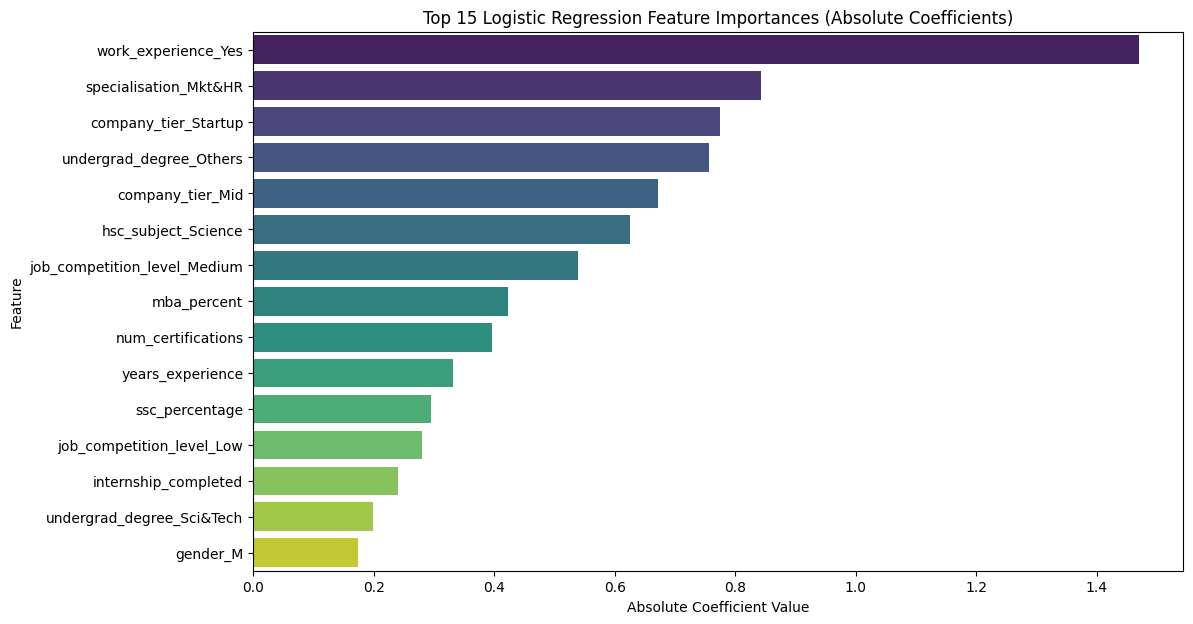

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Abs_Coefficient', y='Feature', data=log_reg_feature_importance.head(15).sort_values(by='Abs_Coefficient', ascending=False), palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Logistic Regression Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

### Random Forest Feature Importance Distribution

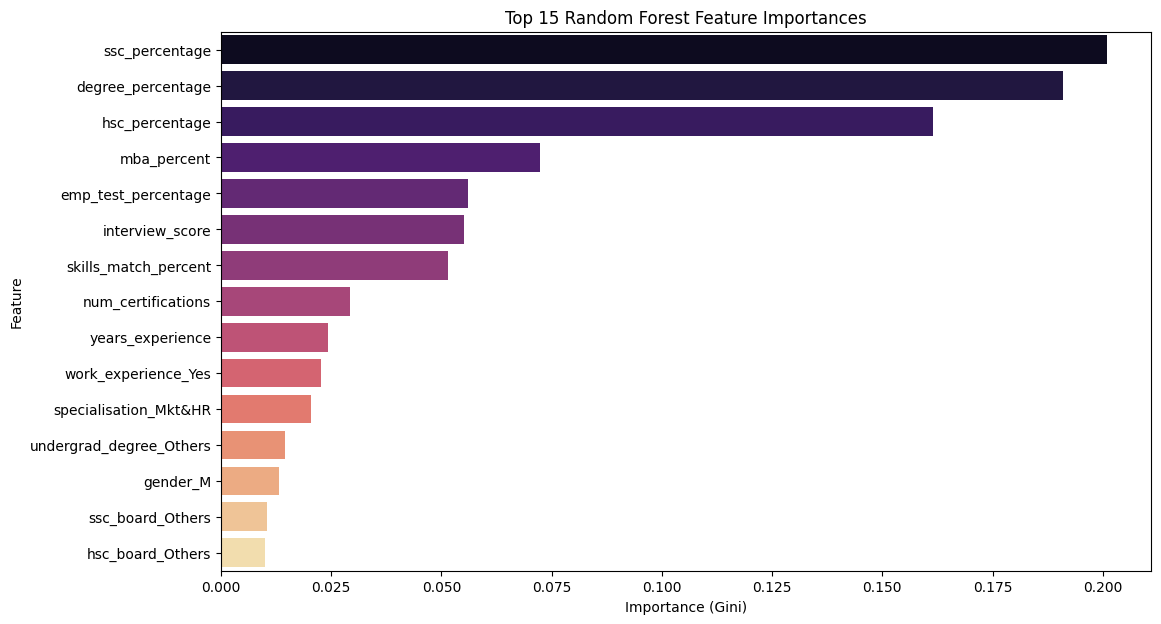

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance.head(15), palette='magma', hue='Feature', legend=False)
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance (Gini)')
plt.ylabel('Feature')
plt.show()

### Decision Tree Feature Importance Distribution

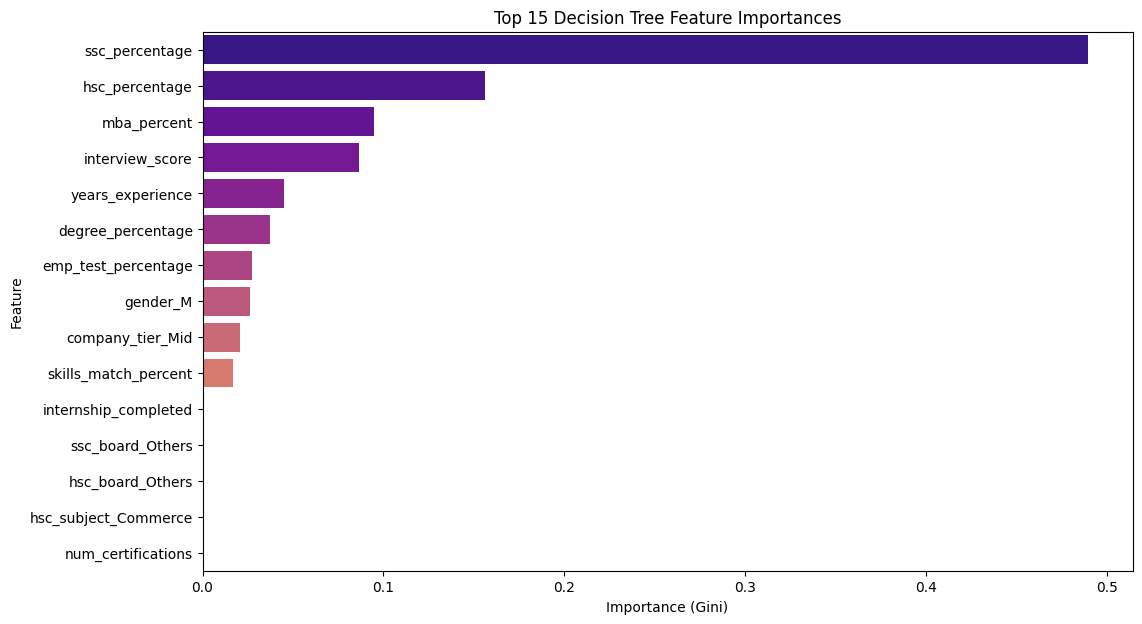

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=dt_feature_importance.head(15), palette='plasma', hue='Feature', legend=False)
plt.title('Top 15 Decision Tree Feature Importances')
plt.xlabel('Importance (Gini)')
plt.ylabel('Feature')
plt.show()

Finally, we want to complete a Chi squared test for each model. Logistic Regression shows we reject the null hypothesis, while we accept null hypothesis for the others.

In [ ]:
contingency_table_log_reg = pd.crosstab(analysis_df['gender_M'], analysis_df['predicted_status_log_reg'])

# Rename indices for clarity
contingency_table_log_reg.index = contingency_table_log_reg.index.map({False: 'Female', True: 'Male'})
contingency_table_log_reg.columns = contingency_table_log_reg.columns.map({0: 'Not Placed', 1: 'Placed'})

print("Contingency Table for Logistic Regression Predictions (Gender vs. Predicted Status):")
print(contingency_table_log_reg)

Contingency Table for Logistic Regression Predictions (Gender vs. Predicted Status):
predicted_status_log_reg  Not Placed  Placed
gender_M                                    
Female                            11      13
Male                               7      34


In [ ]:
from scipy.stats import chi2_contingency

# Perform Chi-squared test on the Logistic Regression predictions contingency table
chi2_statistic_log_reg, p_value_log_reg, degrees_of_freedom_log_reg, expected_frequencies_log_reg = chi2_contingency(contingency_table_log_reg)

print("\nChi-squared Test Results for Logistic Regression Predictions:")
print(f"Chi-squared Statistic: {chi2_statistic_log_reg:.4f}")
print(f"P-value: {p_value_log_reg:.4f}")
print(f"Degrees of Freedom: {degrees_of_freedom_log_reg}")
print("Expected Frequencies (if no association for Log Reg predictions):")
print(expected_frequencies_log_reg.round(2))


Chi-squared Test Results for Logistic Regression Predictions:
Chi-squared Statistic: 4.8996
P-value: 0.0269
Degrees of Freedom: 1
Expected Frequencies (if no association for Log Reg predictions):
[[ 6.65 17.35]
 [11.35 29.65]]


###Our overall Bias Score
We defined a function get_h0_rejection_score to evaluate to 0 or 1 depending on the result of our Chi-Squared test.

In [ ]:
alpha = 0.05 # Significance level

def get_h0_rejection_score(p_value, alpha_level=alpha):
    """
    Returns 1 if the null hypothesis is rejected (p-value < alpha), else 0.
    """
    return 1 if p_value < alpha_level else 0

# Score for Original Data's Chi-squared test
h0_rejected_original = get_h0_rejection_score(p_value)
print(f"Original Data - H0 Rejected Score: {h0_rejected_original}")

# Score for Logistic Regression Predictions' Chi-squared test
h0_rejected_log_reg = get_h0_rejection_score(p_value_log_reg)
print(f"Logistic Regression Predictions - H0 Rejected Score: {h0_rejected_log_reg}")

Original Data - H0 Rejected Score: 0
Logistic Regression Predictions - H0 Rejected Score: 1


We then normalised the feauture importance of gender in our Logistic Regression model to be a score between 0 (no bias towards men) and 1 (biased towards men. Note here that our coefficient was negative (so a bias towards women) however we have shown this as 0 since it shows there is no bias towards men.

In [ ]:
import numpy as np

def calculate_lr_feature_importance(feature_name, lr_feature_importance_df):
    """
    Calculates a normalized importance for a Logistic Regression feature,
    reflecting its original sign. The normalization is based on the absolute
    range of all coefficients, scaling the feature's absolute magnitude to [0,1],
    then applying its original sign.
    """
    all_coefficients = lr_feature_importance_df['Coefficient'].values
    all_abs_coefficients = np.abs(all_coefficients)

    min_abs_coef_global = all_abs_coefficients.min()
    max_abs_coef_global = all_abs_coefficients.max()

    feature_raw_coef = lr_feature_importance_df[lr_feature_importance_df['Feature'] == feature_name]['Coefficient'].iloc[0]
    feature_abs_coef = np.abs(feature_raw_coef)

    # Handle case where all absolute coefficients are the same (or range is zero)
    if max_abs_coef_global == min_abs_coef_global:
        # If all coefficients are 0, importance is 0. If all non-zero and same magnitude,
        # apply sign to a max normalized magnitude (which would be 1 if range > 0).
        result = np.sign(feature_raw_coef) if feature_raw_coef != 0 else 0.0
    else:
        # Normalize the absolute magnitude of the feature's coefficient to a [0, 1] range
        normalized_magnitude = (feature_abs_coef - min_abs_coef_global) / (max_abs_coef_global - min_abs_coef_global)

        # Apply the original sign to the normalized magnitude
        result = np.sign(feature_raw_coef) * normalized_magnitude

    # Ensure the result is not negative, return 0 if it is
    if result < 0:
        return 0.0
    else:
        return result

# Calculate the normalized importance for 'gender_M'
gender_m_normalized_lr_importance = calculate_lr_feature_importance('gender_M', log_reg_feature_importance.copy())

print(f"Normalized Logistic Regression Importance for 'gender_M': {gender_m_normalized_lr_importance:.4f}")

Normalized Logistic Regression Importance for 'gender_M': 0.0000


Our decision tree and random forest model is easier to normalise between 0 and 1.

In [ ]:
import numpy as np

def calculate_tree_feature_importance(feature_name, tree_feature_importance_df):
    """
    Calculates the normalized importance (0-1 scale) of a feature
    from tree-based model feature importances.
    """
    min_importance = tree_feature_importance_df['Importance'].min()
    max_importance = tree_feature_importance_df['Importance'].max()

    if max_importance == min_importance:
        return 0.0 # All importances are the same or all are zero

    feature_importance = tree_feature_importance_df[tree_feature_importance_df['Feature'] == feature_name]['Importance'].iloc[0]
    normalized_importance = (feature_importance - min_importance) / (max_importance - min_importance)
    return normalized_importance

# Calculate the normalized importance for 'gender_M' for Random Forest
gender_m_normalized_rf_importance = calculate_tree_feature_importance('gender_M', rf_feature_importance.copy())

# Calculate the normalized importance for 'gender_M' for Decision Tree
gender_m_normalized_dt_importance = calculate_tree_feature_importance('gender_M', dt_feature_importance.copy())

print(f"Normalized Random Forest Importance for 'gender_M': {gender_m_normalized_rf_importance:.4f}")
print(f"Normalized Decision Tree Importance for 'gender_M': {gender_m_normalized_dt_importance:.4f}")

Normalized Random Forest Importance for 'gender_M': 0.0326
Normalized Decision Tree Importance for 'gender_M': 0.0534


Now for the fun stuff. We use the normalised feature importance, the DIR, and the Chi squared test in our formula. Note we used 1-DIR (if less than 1), 0 if DIR is 1 (fair) and 1 if DIR is 0 (biased). We calculated the weighted average using our custom equation below.

In [ ]:
# Calculate combined bias score for each model
# (weighted combination of chi-squared result, feature importance, and disparate impact ratio)

# Define weights (adjust these based on how much you want to emphasize each component)
weight_chi = 0.2           # Weight for chi-squared test result
weight_importance = 0.4    # Weight for feature importance
weight_disparate = 0.4     # Weight for disparate impact ratio

print("\n" + "="*70)
print("COMBINED MODEL BIAS SCORES (Weights: {:.0%} Chi² + {:.0%} Importance + {:.0%} Disparate Impact)".format(
    weight_chi, weight_importance, weight_disparate))
print("="*70)

# Get disparate impact ratios from your DataFrame
disparate_ratio_original = 0.8779
disparate_ratio_log_reg = 0.6532
disparate_ratio_rf = 0.8542
disparate_ratio_dt = 0.8542

# Convert disparate impact to a 0-1 bias score
# For females as protected group:
# - Ratio < 1 means bias against females (fewer positive outcomes)
# - Ratio > 1 means bias against males (more positive outcomes for females)
def disparate_to_bias_score(ratio):
    """
    Convert disparate impact ratio to a 0-1 bias score.
    For females as protected group:
    - 1.0 = no bias (score 0)
    - < 1.0 = bias against females (score increases as ratio decreases from 1)
    - > 1.0 = bias against males (score increases as ratio increases from 1)
    """
    if ratio >= 1:
        # Bias against males
        return min(ratio - 1, 1)  # Cap at 1
    else:
        # Bias against females
        return min(1 - ratio, 1)  # Cap at 1

# Logistic Regression combined score
log_reg_chi_component = weight_chi * h0_rejected_log_reg
log_reg_imp_component = weight_importance * gender_m_normalized_lr_importance
log_reg_disparate_component = weight_disparate * disparate_to_bias_score(disparate_ratio_log_reg)
log_reg_combined = log_reg_chi_component + log_reg_imp_component + log_reg_disparate_component

print(f"\nLogistic Regression Combined Bias Score: {log_reg_combined:.4f}")
print(f"  - Chi-squared component: {h0_rejected_log_reg} × {weight_chi} = {log_reg_chi_component}")
print(f"  - Importance component: {gender_m_normalized_lr_importance:.4f} × {weight_importance} = {log_reg_imp_component:.4f}")
print(f"  - Disparate Impact component: {disparate_ratio_log_reg:.4f} ratio → {disparate_to_bias_score(disparate_ratio_log_reg):.4f} bias × {weight_disparate} = {log_reg_disparate_component:.4f}")

# Random Forest combined score
rf_chi_component = weight_chi * h0_rejected_log_reg
rf_imp_component = weight_importance * gender_m_normalized_rf_importance
rf_disparate_component = weight_disparate * disparate_to_bias_score(disparate_ratio_rf)
rf_combined = rf_chi_component + rf_imp_component + rf_disparate_component

print(f"\nRandom Forest Combined Bias Score: {rf_combined:.4f}")
print(f"  - Chi-squared component: {h0_rejected_log_reg} × {weight_chi} = {rf_chi_component}")
print(f"  - Importance component: {gender_m_normalized_rf_importance:.4f} × {weight_importance} = {rf_imp_component:.4f}")
print(f"  - Disparate Impact component: {disparate_ratio_rf:.4f} ratio → {disparate_to_bias_score(disparate_ratio_rf):.4f} bias × {weight_disparate} = {rf_disparate_component:.4f}")

# Decision Tree combined score
dt_chi_component = weight_chi * h0_rejected_log_reg
dt_imp_component = weight_importance * gender_m_normalized_dt_importance
dt_disparate_component = weight_disparate * disparate_to_bias_score(disparate_ratio_dt)
dt_combined = dt_chi_component + dt_imp_component + dt_disparate_component

print(f"\nDecision Tree Combined Bias Score: {dt_combined:.4f}")
print(f"  - Chi-squared component: {h0_rejected_log_reg} × {weight_chi} = {dt_chi_component}")
print(f"  - Importance component: {gender_m_normalized_dt_importance:.4f} × {weight_importance} = {dt_imp_component:.4f}")
print(f"  - Disparate Impact component: {disparate_ratio_dt:.4f} ratio → {disparate_to_bias_score(disparate_ratio_dt):.4f} bias × {weight_disparate} = {dt_disparate_component:.4f}")

# Original Data combined score (for reference)
original_chi_component = weight_chi * h0_rejected_original
original_disparate_component = weight_disparate * disparate_to_bias_score(disparate_ratio_original)
original_combined = original_chi_component + original_disparate_component

print(f"\nOriginal Data Combined Bias Score: {original_combined:.4f} (for reference)")
print(f"  - Chi-squared component: {h0_rejected_original} × {weight_chi} = {original_chi_component}")
print(f"  - Disparate Impact component: {disparate_ratio_original:.4f} ratio → {disparate_to_bias_score(disparate_ratio_original):.4f} bias × {weight_disparate} = {original_disparate_component:.4f}")

# Summary comparison
print("\n" + "-"*70)
print("SUMMARY - Combined Bias Scores (0-1 scale):")
print(f"Original Data:       {original_combined:.4f} (baseline)")
print(f"Logistic Regression: {log_reg_combined:.4f}")
print(f"Random Forest:       {rf_combined:.4f}")
print(f"Decision Tree:       {dt_combined:.4f}")
print("-"*70)

# Store in dictionary
model_combined_scores = {
    'original_data': original_combined,
    'logistic_regression': log_reg_combined,
    'random_forest': rf_combined,
    'decision_tree': dt_combined
}

print("\nInterpretation (0-1 scale, higher = more bias):")
print("0.00-0.33 = Low bias")
print("0.34-0.66 = Moderate bias")
print("0.67-1.00 = High bias")


COMBINED MODEL BIAS SCORES (Weights: 20% Chi² + 40% Importance + 40% Disparate Impact)

Logistic Regression Combined Bias Score: 0.3387
  - Chi-squared component: 1 × 0.2 = 0.2
  - Importance component: 0.0000 × 0.4 = 0.0000
  - Disparate Impact component: 0.6532 ratio → 0.3468 bias × 0.4 = 0.1387

Random Forest Combined Bias Score: 0.2714
  - Chi-squared component: 1 × 0.2 = 0.2
  - Importance component: 0.0326 × 0.4 = 0.0130
  - Disparate Impact component: 0.8542 ratio → 0.1458 bias × 0.4 = 0.0583

Decision Tree Combined Bias Score: 0.2797
  - Chi-squared component: 1 × 0.2 = 0.2
  - Importance component: 0.0534 × 0.4 = 0.0214
  - Disparate Impact component: 0.8542 ratio → 0.1458 bias × 0.4 = 0.0583

Original Data Combined Bias Score: 0.0488 (for reference)
  - Chi-squared component: 0 × 0.2 = 0.0
  - Disparate Impact component: 0.8779 ratio → 0.1221 bias × 0.4 = 0.0488

----------------------------------------------------------------------
SUMMARY - Combined Bias Scores (0-1 scale)

### Overall Bias Score Comparison

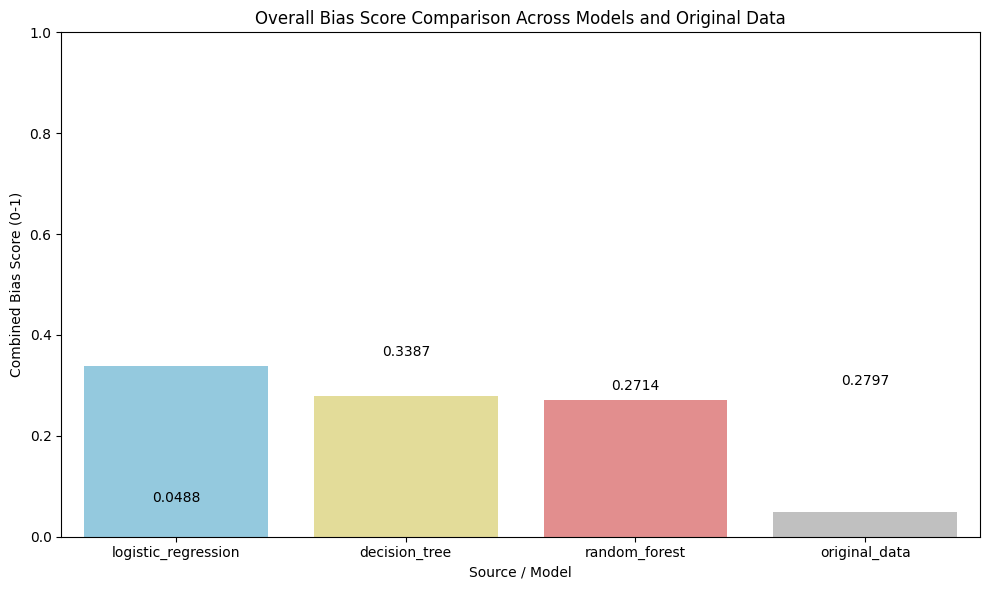

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the dictionary of combined scores into a DataFrame for plotting
bias_scores_df = pd.DataFrame(model_combined_scores.items(), columns=['Source/Model', 'Combined Bias Score'])

# Sort for better visualization (optional)
bias_scores_df = bias_scores_df.sort_values(by='Combined Bias Score', ascending=False)

# Define the custom color palette to match previous DIR graph
custom_bias_palette = {
    'original_data': 'silver',
    'logistic_regression': 'skyblue',
    'random_forest': 'lightcoral',
    'decision_tree': 'khaki'
}

plt.figure(figsize=(10, 6))
sns.barplot(x='Source/Model', y='Combined Bias Score', data=bias_scores_df, palette=custom_bias_palette, hue='Source/Model', legend=False)

# Add labels and title
plt.title('Overall Bias Score Comparison Across Models and Original Data')
plt.xlabel('Source / Model')
plt.ylabel('Combined Bias Score (0-1)')
plt.ylim(0, 1.0) # Ensure y-axis is from 0 to 1 for consistent comparison

# Display the score values on top of the bars
for index, row in bias_scores_df.iterrows():
    plt.text(index, row['Combined Bias Score'] + 0.02, f"{row['Combined Bias Score']:.4f}", color='black', ha="center")

plt.tight_layout()
plt.show()

###Conclusion

We can see logistic regression models are slightly too biased, even though the feature importance of the male gender was negative to try combat this. We have used our overall bias score to clearly show this.